# Regresión logística con StudentsPerformance

Dividiremos este notebook en los siguientes puntos:

1. Análisis inicial de los datos.

2. Implementación desde cero del modelo.

3. Entrenamiento y evaluación. 

In [1]:
import pandas as pd
import numpy as np
import scipy.optimize as op
from scipy.optimize import fmin_cg
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#from sklearn import metrics
import math
import matplotlib.pyplot as plt

### 1. Análisis inicial de los datos

In [2]:
#Carga del dataset
df = pd.read_csv('StudentsPerformance.csv')

In [3]:
#visualizacion del dataset
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


En nuestro caso podemos comprobar que las dimensiones de nuestro dataset son de 1000 filas(estudiantes) x 8 coumnas(atributos).  Tres atributos son numéricos (math_score, reading score y writing score) y el resto categóricos.

In [6]:
#Comprobamos si hay algun valor nulo o faltante
df.isnull().any().any()

False

Al no  haber ningún dato faltante no se requiere sustituir ni reemplazar nada.

Para nuestro modelo regresión logística no se requiere normalizar o estandarizar ya que todas las variables numéricas tienen rangos similares, es decir, los tres scores están entre 0 y 100, por lo que están en la misma escala.
Las variables categóricas que convertiremos a dummies tomarán valores 0/1, compatibles con esta escala.

Vamos a crear una variable categórica a partir del atributo math score, que determinará si un alumno pasa o no pasa en función de un umbral. El motivo de esta decisión es porque se alinea con el objetivo principal del dataset, que es medir el rendimiento académico de los estudiantes, y porque de esta forma tenemos un problema de clasificación binaria y no multiclase.

Dicha variable categórica se llamará "passed_math" y será nuestra variable objetivo. Y el resto de categóricas se convertirán a numéricas mediante one-hot encoding.

In [7]:
#Creacion variable objetivo
df["passed_math"] = np.where(df['math score'] >= 60, 1, 0)

In [8]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,passed_math
0,female,group B,bachelor's degree,standard,none,72,72,74,1
1,female,group C,some college,standard,completed,69,90,88,1
2,female,group B,master's degree,standard,none,90,95,93,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,0
4,male,group C,some college,standard,none,76,78,75,1
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,1
996,male,group C,high school,free/reduced,none,62,55,55,1
997,female,group C,high school,free/reduced,completed,59,71,65,0
998,female,group D,some college,standard,completed,68,78,77,1


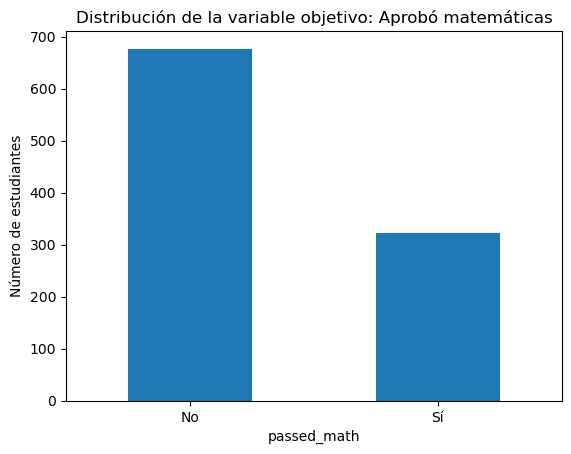

In [9]:
#Distribución de la variable objetivo "passed_math"
df["passed_math"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo: Aprobó matemáticas")
plt.xticks([0,1], ["No", "Sí"], rotation=0)
plt.ylabel("Número de estudiantes")
plt.show()


In [10]:
#Analizamos la correlación de la variable numérica math score con respecto a las otras dos variables numéricas
corr = df[["math score", "reading score", "writing score"]].corr()
corr


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


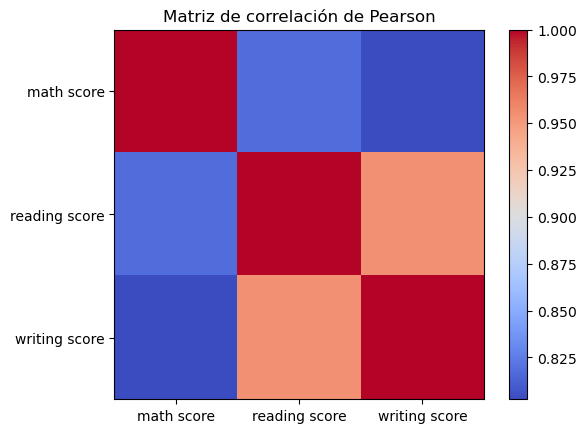

In [11]:
#Representación grafica de la matriz de correlación
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)
plt.title("Matriz de correlación de Pearson")
plt.show()

Observamos que las tres variables numéricas están altamente correlacionadas entre sí y por tanto no deben eliminarse porque el entrenamiento del modelo y su capacidad de predicción perderían bastante calidad.

### 2. Implementación desde cero del modelo

In [12]:
# Datos de entrada
X = df.drop(["math score", "passed_math"], axis=1)
# Variable objetivo a predecir
y = df["passed_math"]

# One-hot encoding para las variables categóricas
X = pd.get_dummies(X, drop_first=True).to_numpy(dtype=np.float64) # Convertimos a NumPy array
# añadimos columna unos
X = np.insert(X, 0, 1, axis=1) # Se inserta una columna de unos al inicio

# Inicializamos theta 
num_atributos = X.shape[1]
initial_theta = np.zeros(num_atributos, dtype=np.float64)

In [13]:
#Inicializamos theta
num_atributos = X.shape[1]
initial_theta = np.zeros((num_atributos,1), dtype=np.float64)

Implementamos las mismas fuciones vistas en la epd de la asignatura

In [14]:
#definimos la funcion sigmoide

def sigmoid(z):
    den = 1 + np.exp(-z)
    g = 1 / den
    return g

In [15]:
def costFunction(theta, X, y):
    m = len(y)
    
    # theta  vector columna tipo NumPy
    theta = np.array(theta).reshape(-1, 1) 
    
    #  y   vector columna tipo NumPy
   
    y_array = y.to_numpy().reshape(-1, 1) 
    
   
    h = sigmoid(np.dot(X, theta)) 
    
    
    
    epsilon = 1e-10
    J = (-1 / m) * np.sum((y_array * np.log(h + epsilon)) + 
                         ((1 - y_array) * np.log(1 - h + epsilon)))
    
   
    return J



In [16]:
#Funcion descenso del gradiente 
def gradientFunction(theta, X, y):
    m = len(y)
    
    # theta  vector columna tipo NumPy
    theta = np.array(theta).reshape(-1, 1)
    
    #  y  vector columna tipo NumPy
    y_array = y.to_numpy().reshape(-1, 1) 
    
    h = sigmoid(np.dot(X, theta))
    
    # calculo gradiente
    grad = (1 / m) * (X.T @ (h - y_array))
    
    # fmin_cg espera el gradiente como un array unidimensional
    return grad.flatten()

In [17]:
# Funcion predict
def predict(theta, X):
    
    # Aseguramos que theta sea un vector columna de NumPy
    theta = np.array(theta).reshape(-1, 1)
    
   
    probabilities = sigmoid(np.dot(X, theta))
    
    
    prediction = (probabilities >= 0.5).astype(int)
    return prediction

In [18]:
# Función callback para gráfico convergencia

cost_history = []
def callback_func(xk): 
   
    global cost_history
    
    current_cost = costFunction(xk, X, y) 
    cost_history.append(current_cost)

In [19]:
#Training


theta_opt_result = fmin_cg(f=costFunction, x0=initial_theta, fprime=gradientFunction, args=(X, y),maxiter=400,full_output=True,disp=True, callback=callback_func )

#Obtenemos  theta óptimo
theta_opt = theta_opt_result[0]

         Current function value: 0.222726
         Iterations: 400
         Function evaluations: 987
         Gradient evaluations: 984


C:\Users\varea.LAPTOP-P3D215RM\anaconda3\envs\entornoIA2425\lib\site-packages\scipy\optimize\_optimize.py:1659: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(f, x0, args, fprime, callback=callback, c1=c1, c2=c2,


In [20]:
# Prediccion

p = predict(theta_opt, X)


y_array = y.to_numpy().reshape(-1, 1)
accuracy = np.mean(p == y_array) * 100

print("Precisión del modelo: ", accuracy,"%")

Precisión del modelo:  90.5 %


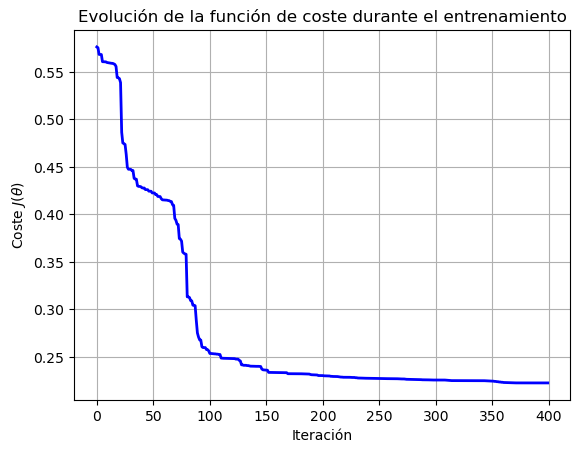

In [21]:
#Gráfico de convergencia

plt.figure()
plt.plot(range(len(cost_history)), cost_history, color='blue', linewidth=2)
plt.title('Evolución de la función de coste durante el entrenamiento')
plt.xlabel('Iteración')
plt.ylabel('Coste $J(\\theta)$')
plt.grid(True)
plt.show()

### 3.  Entrenamiento y evaluación

In [22]:
#Separacion del conjunto en datos de prueba y datos de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
#Prediccion sobre el conjunto de prueba
p_test = predict(theta_opt, X_test)

#Convertimos y_test a un array tipo NumPy para la comparación
y_test_array = y_test.to_numpy().reshape(-1, 1)



#Tasa de acierto
accuracy = np.mean(p_test == y_test_array) * 100

#Matriz de Confusión
cm = confusion_matrix(y_test_array, p_test)

print("\nResultados de la Evaluación")

print("Precisión del modelo en el conjunto de prueba: ", accuracy,"%")

print("\nMatriz de Confusión:")
print(cm)


Resultados de la Evaluación
Precisión del modelo en el conjunto de prueba:  91.66666666666666 %

Matriz de Confusión:
[[ 82  15]
 [ 10 193]]


Observamos que de 203 alumnos que aprobaron, el modelo predijo correctamente 193 que son los verdaderos positivos y predijo erróneamente 10 que son los falsos positivos.
Asimismo,  de 97 alumnos suspensos, el modelo predijo correctamente 82 suspensos (verdaderos negativos) y 
erróneamente 15 suspensos (falsos negativos).